In [1]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit

/tmp/ipykernel_812529/116530095.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
if not os.path.exists(os.path.normpath('figures/')):
    os.makedirs(os.path.normpath('figures/'))

# Fig. 1

In [3]:
color_dict = {
    'FMS': 'tab:blue',
    'NeuroSAT': 'tab:orange',
    'SP': 'tab:green',
    'SA': 'tab:red',
    'QuerySAT': 'tab:purple',
    'BP': 'tab:cyan',
    'rPI-GNN': 'tab:olive'
}

def plot_solvability_curve(data, N, legend_dict, task='SAT', value='probability', savename=None):
    assert value in ['probability', 'energy'], "plotting functions supports only probabilities or energies on the y axis" 

    if value == 'probability':
        y_col, err_col = 'ProbSolv', 'ProbSolv_err'
    else:
        y_col, err_col = 'E_mean', 'E_err'

    grouped_df = data.groupby('algo')
    for algo, group in grouped_df:
        if (legend_dict[algo] == 'SP' and value == 'energy'):
            continue
        group = group[group.N == N]
        alpha = group['alpha'].values
        p, err = group[y_col].values, group[err_col].values
        plt.errorbar(alpha, p, yerr=err, fmt='-o', label=f'{legend_dict[algo]}', color=color_dict[legend_dict[algo]])
        
        if value == 'energy':
            plt.yscale('log')
            
    if 'SAT' in task:
        plt.xlabel('α', fontsize=18)
    else:
        plt.xlabel('c', fontsize=18)
        
    plt.xticks(fontsize=14)
    y_label = 'P' if value == 'probability' else 'E'
    plt.ylabel(y_label, fontsize=18)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=14)
    plt.tight_layout()
    if savename:
        plt.savefig(os.path.join('figures', savename), format="pdf")
    plt.show()

In [4]:
res_3sat = pd.read_csv(os.path.abspath('../results_evaluation/analysis-results/3SAT-summary.csv'))
algorithms = sorted(['FMS_nsteps=100N^2', 'NeuroSAT_unsupervised_niters=2N_Ntrain=256', \
               'SurveyPropagation_frac-decimated=0.00125', 'SimulatedAnnealing_nsteps=1000N^2', 'QuerySAT_niters=2N_Ntrain=256'])
algo_names = sorted(['FMS', 'NeuroSAT', 'SP', 'SA', 'QuerySAT'])
res_3sat.algo.unique()
legend_dict = dict(zip(algorithms, algo_names))
res_3sat = res_3sat[res_3sat['algo'].isin(algorithms)]
res_3sat['alpha'] = res_3sat['M'] / res_3sat['N']
res_3sat = res_3sat.drop_duplicates()
res_3sat

,algo,N,M,count,E_mean,E_err,ProbSolv,ProbSolv_err,alpha
483,FMS_nsteps=100N^2,16,48,400,0.0000,0.000000,1.0000,0.000000,3.000000
484,FMS_nsteps=100N^2,16,50,400,0.0050,0.003531,0.9950,0.003531,3.125000
485,FMS_nsteps=100N^2,16,51,400,0.0100,0.004981,0.9900,0.004981,3.187500
486,FMS_nsteps=100N^2,16,53,400,0.0025,0.002500,0.9975,0.002500,3.312500
487,FMS_nsteps=100N^2,16,54,400,0.0125,0.005562,0.9875,0.005562,3.375000
...,...,...,...,...,...,...,...,...,...
1738,SimulatedAnnealing_nsteps=1000N^2,1024,4710,400,10.3175,0.105271,0.0000,0.000000,4.599609
1739,SimulatedAnnealing_nsteps=1000N^2,1024,4813,400,13.5700,0.116659,0.0000,0.000000,4.700195
1740,SimulatedAnnealing_nsteps=1000N^2,1024,4915,400,17.4500,0.128003,0.0000,0.000000,4.799805
1741,SimulatedAnnealing_nsteps=1000N^2,1024,5018,400,21.0350,0.127917,0.0000,0.000000,4.900391


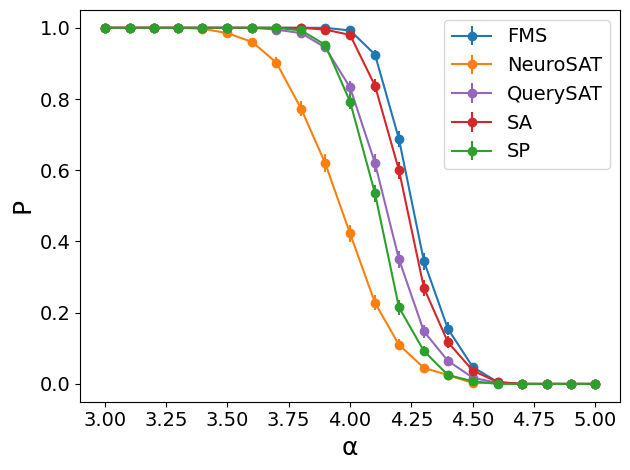

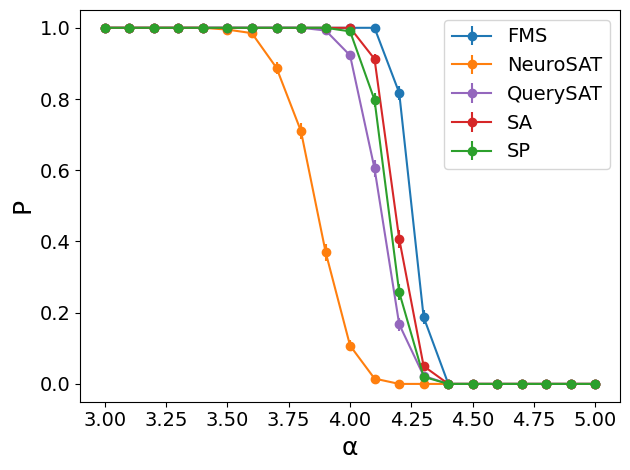

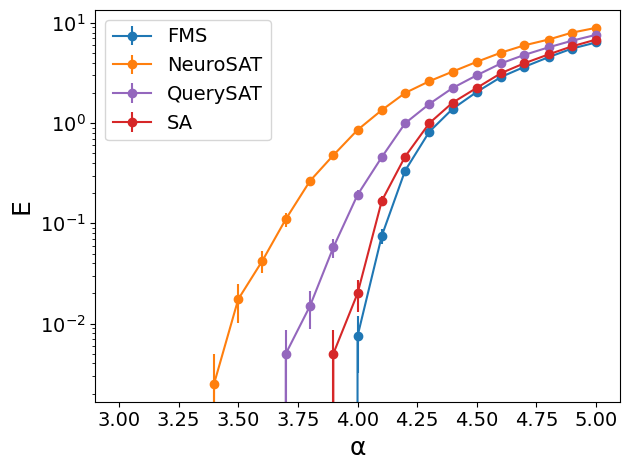

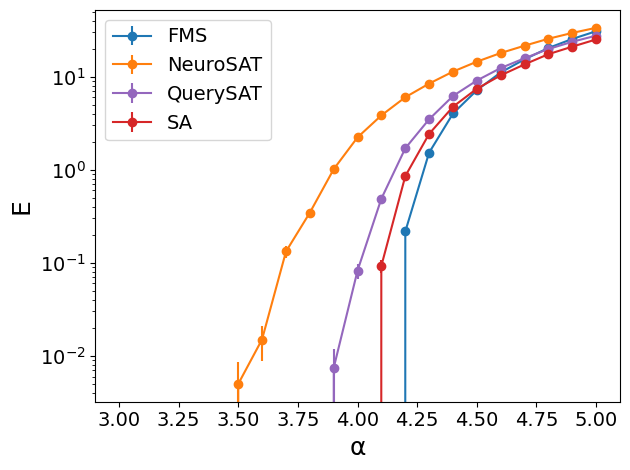

In [5]:
plot_solvability_curve(res_3sat, 256, legend_dict, task='3SAT', savename='fig1_3sat_256.pdf')
plot_solvability_curve(res_3sat, 1024, legend_dict, task='3SAT', savename='fig1_3sat_1024.pdf')
plot_solvability_curve(res_3sat, 256, legend_dict, task='3SAT', value='energy', savename='E_3SAT_256.pdf')
plot_solvability_curve(res_3sat, 1024, legend_dict, task='3SAT', value='energy', savename='E_3SAT_1024.pdf')

In [6]:
res_4sat = pd.read_csv(os.path.abspath('../results_evaluation/analysis-results/4SAT-summary.csv'))
res_4sat.algo.value_counts()

algo
SurveyPropagation_frac-decimated=0.00125      231
NeuroSAT_unsupervised_niters=2N_Ntrain=256    168
QuerySAT_niters=2N_Ntrain=256                 168
FMS_nsteps=100N^2                             168
FMS_nsteps=1000N^2                            147
SimulatedAnnealing_nsteps=1000N^2             147
Name: count, dtype: int64

In [7]:
res_4sat = pd.read_csv(os.path.abspath('../results_evaluation/analysis-results/4SAT-summary.csv'))
algorithms = sorted(['FMS_nsteps=100N^2', 'NeuroSAT_unsupervised_niters=2N_Ntrain=256', 'SurveyPropagation_frac-decimated=0.00125', 'SimulatedAnnealing_nsteps=1000N^2', 'QuerySAT_niters=2N_Ntrain=256'])
algo_names = sorted(['FMS', 'NeuroSAT', 'SP', 'SA', 'QuerySAT'])
legend_dict = dict(zip(algorithms, algo_names))
res_4sat = res_4sat[res_4sat['algo'] != 'FMS_nsteps=1000N^2']
res_4sat['alpha'] = res_4sat['M'] / res_4sat['N']
res_4sat = res_4sat.drop_duplicates()
res_4sat

,algo,N,M,count,E_mean,E_err,ProbSolv,ProbSolv_err,alpha
147,NeuroSAT_unsupervised_niters=2N_Ntrain=256,16,128,200,0.210,0.030564,0.800,0.028355,8.000000
148,NeuroSAT_unsupervised_niters=2N_Ntrain=256,16,130,200,0.200,0.028355,0.800,0.028355,8.125000
149,NeuroSAT_unsupervised_niters=2N_Ntrain=256,16,131,200,0.215,0.029973,0.790,0.028873,8.187500
150,NeuroSAT_unsupervised_niters=2N_Ntrain=256,16,133,200,0.195,0.028086,0.805,0.028086,8.312500
151,NeuroSAT_unsupervised_niters=2N_Ntrain=256,16,134,200,0.225,0.032822,0.790,0.028873,8.375000
...,...,...,...,...,...,...,...,...,...
1024,FMS_nsteps=100N^2,2048,19661,200,0.000,0.000000,1.000,0.000000,9.600098
1025,FMS_nsteps=100N^2,2048,19866,200,0.055,0.017647,0.950,0.015450,9.700195
1026,FMS_nsteps=100N^2,2048,20070,200,0.540,0.051039,0.565,0.035143,9.799805
1027,FMS_nsteps=100N^2,2048,20275,200,2.155,0.089974,0.070,0.018087,9.899902


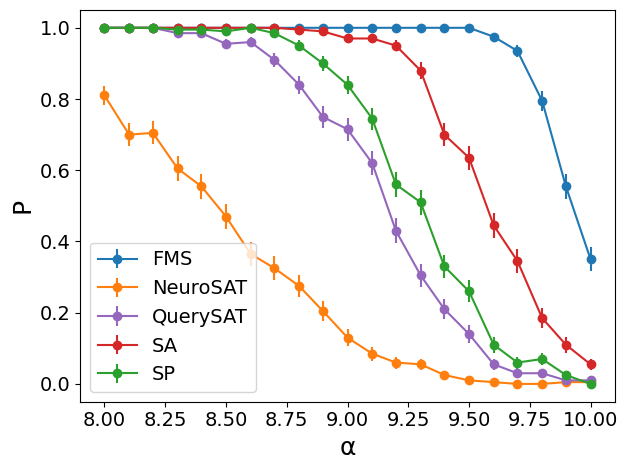

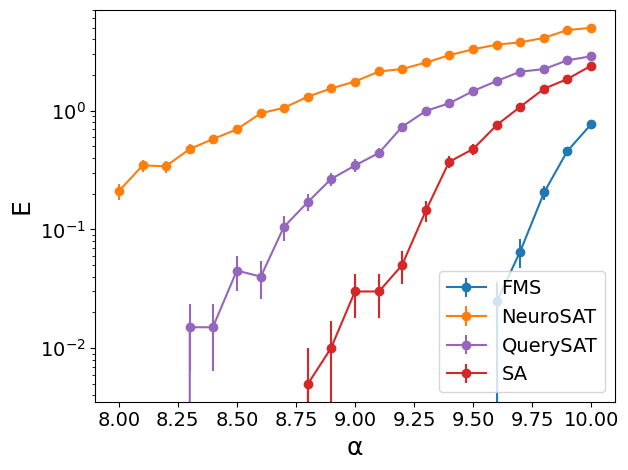

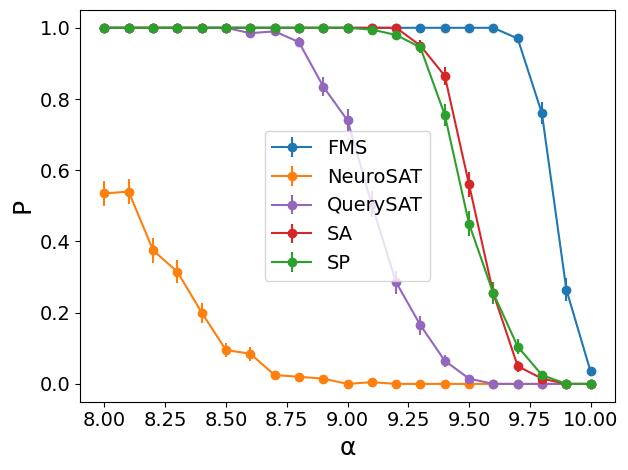

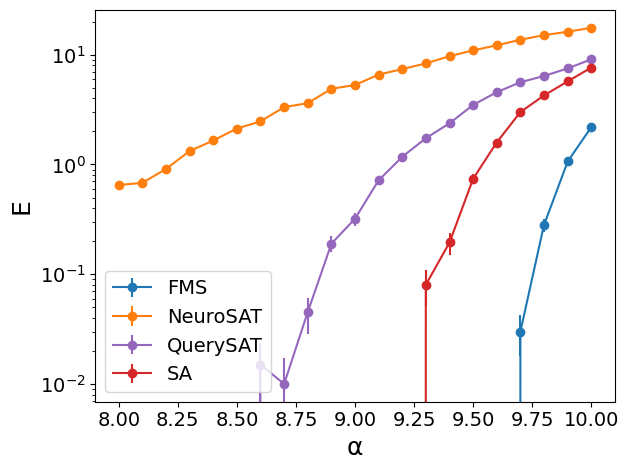

In [8]:
plot_solvability_curve(res_4sat, 256, legend_dict, task='4SAT', savename='fig1_4sat_256.pdf')
plot_solvability_curve(res_4sat, 256, legend_dict, task='4SAT', value='energy', savename='E_4SAT_256.pdf')
plot_solvability_curve(res_4sat, 1024, legend_dict, task='4SAT', savename='fig1_4sat_1024.pdf')
plot_solvability_curve(res_4sat, 1024, legend_dict, task='4SAT', value='energy', savename='E_4SAT_1024.pdf')

In [9]:
res_3col = pd.read_csv(os.path.abspath('../results_evaluation/analysis-results/3COL-summary.csv'))
algorithms = sorted(['BeliefPropagation_frac-decimated=1overN', 'SimulatedAnnealing_nsteps=1000N^2', \
                      'FMScol_eta=0.37_nsteps=625N^2', 'rPI-GNN_ntrials=5', 'QuerySAT_nsteps=2N'])
algo_names = sorted(['BP', 'SA', 'FMS', 'rPI-GNN', 'QuerySAT'])
legend_dict = dict(zip(algorithms, algo_names))
res_3col = res_3col[res_3col['algo'].isin(algorithms)]
res_3col['alpha'] = (res_3col['M'] / res_3col['N']) * 2
res_3col = res_3col[res_3col['alpha'] > 3.25]
res_3col = res_3col.drop_duplicates()

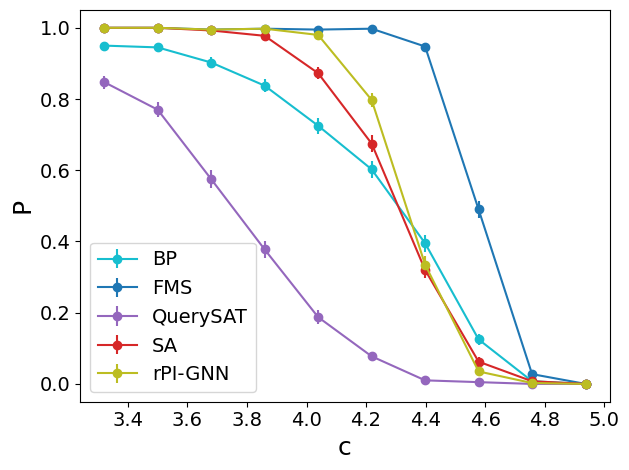

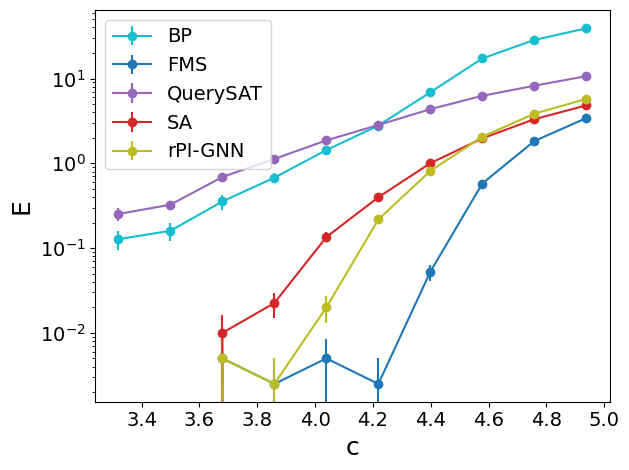

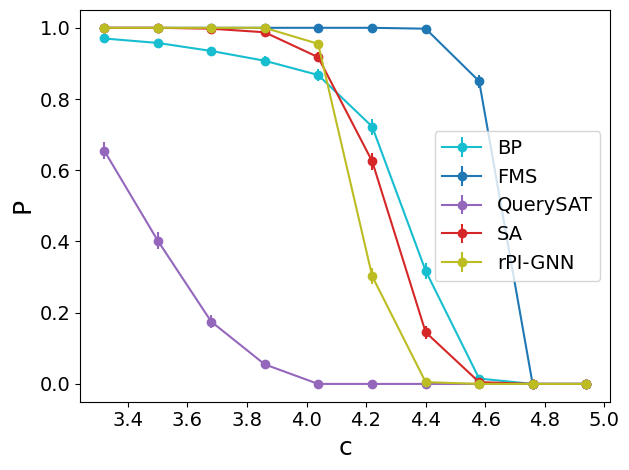

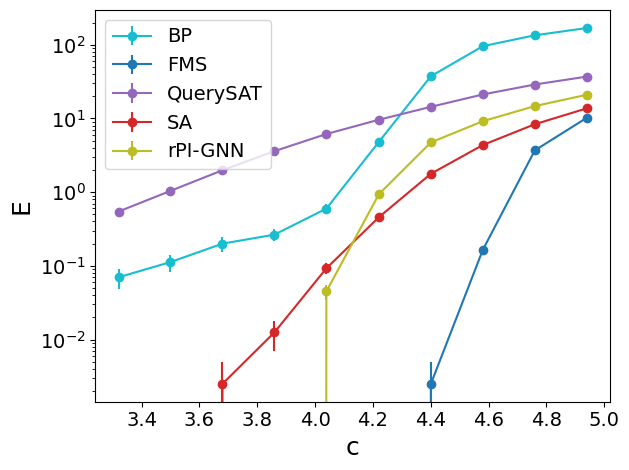

In [10]:
plot_solvability_curve(res_3col, 256, legend_dict, task='3COL', savename='fig1_3col_256.pdf')
plot_solvability_curve(res_3col, 256, legend_dict, task='3COL', value='energy', savename='E_3COL_256.pdf')
plot_solvability_curve(res_3col, 1024, legend_dict, task='3COL', savename='fig1_3col_1024.pdf')
plot_solvability_curve(res_3col, 1024, legend_dict, task='3COL', value='energy', savename='E_3COL_1024.pdf')

In [11]:
res_5col = pd.read_csv(os.path.abspath('../results_evaluation/analysis-results/5COL-summary.csv'))
algorithms = sorted(['BeliefPropagation_frac-decimated=1overN', 'SimulatedAnnealing_nsteps=1000N^2', \
                      'FMScol_eta=0.25_nsteps=625N^2', 'rPI-GNN_ntrials=5', 'QuerySAT_nsteps=2N'])
algo_names = sorted(['BP', 'SA', 'FMS', 'rPI-GNN', 'QuerySAT'])
legend_dict = dict(zip(algorithms, algo_names))
res_5col = res_5col[res_5col['algo'].isin(algorithms)]
res_5col['alpha'] = (res_5col['M'] / res_5col['N']) * 2
res_5col = res_5col.drop_duplicates()
res_5col

,algo,N,M,count,E_mean,E_err,ProbSolv,ProbSolv_err,alpha
0,FMScol_eta=0.25_nsteps=625N^2,16,79,400,2.2275,0.034711,0.005,0.003531,9.875000
1,FMScol_eta=0.25_nsteps=625N^2,16,82,400,2.6525,0.036848,0.000,0.000000,10.250000
2,FMScol_eta=0.25_nsteps=625N^2,16,86,400,3.3775,0.037796,0.000,0.000000,10.750000
3,FMScol_eta=0.25_nsteps=625N^2,16,89,400,3.9650,0.036917,0.000,0.000000,11.125000
4,FMScol_eta=0.25_nsteps=625N^2,16,92,400,4.6125,0.036182,0.000,0.000000,11.500000
...,...,...,...,...,...,...,...,...,...
469,rPI-GNN_ntrials=5,4096,21914,400,0.0000,0.000000,1.000,0.000000,10.700195
470,rPI-GNN_ntrials=5,4096,22733,400,0.0000,0.000000,1.000,0.000000,11.100098
471,rPI-GNN_ntrials=5,4096,23552,400,1.5775,0.088485,0.325,0.023448,11.500000
472,rPI-GNN_ntrials=5,4096,24371,400,10.9225,0.175551,0.000,0.000000,11.899902


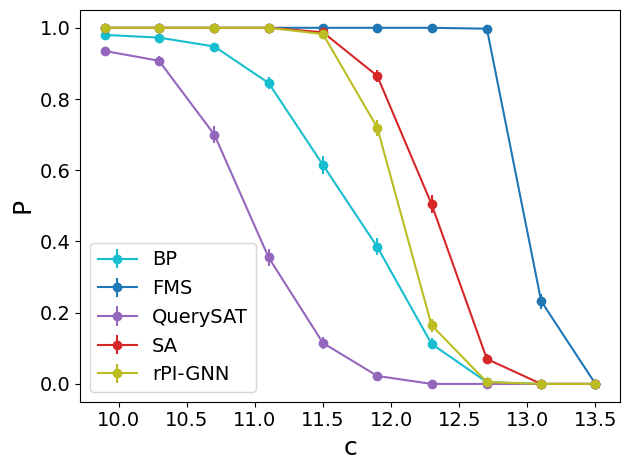

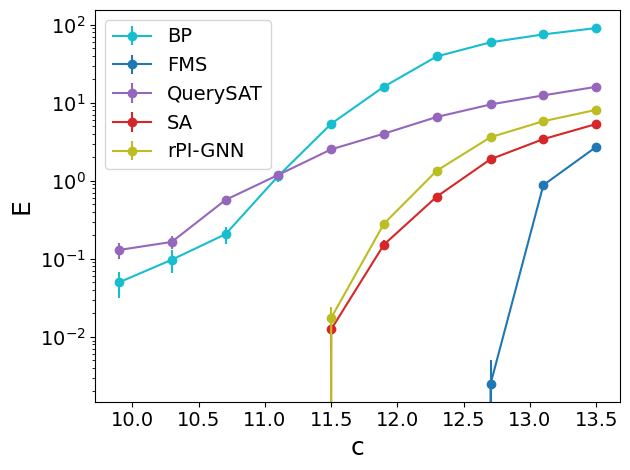

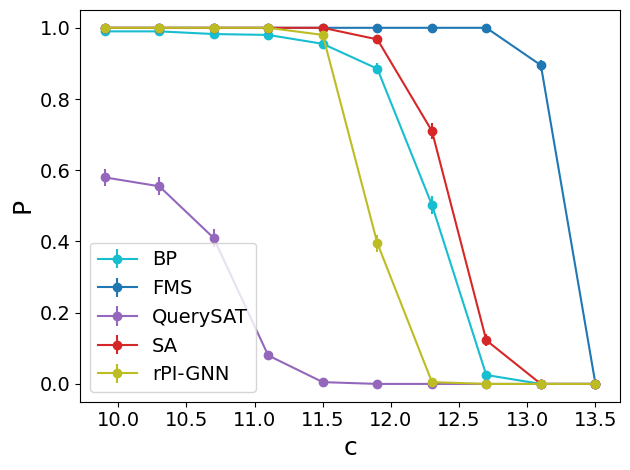

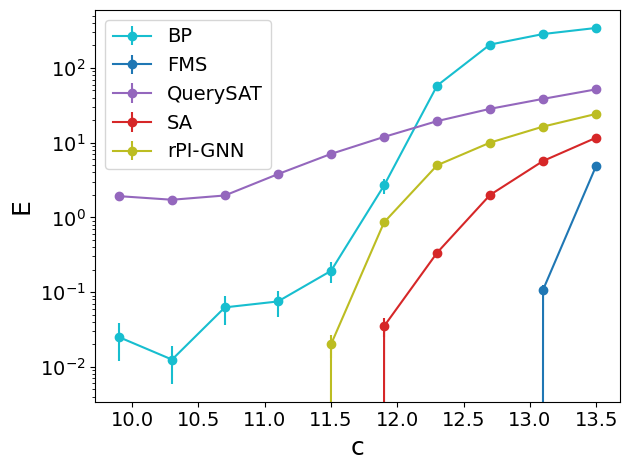

In [12]:
plot_solvability_curve(res_5col, 256, legend_dict, task='5COL', savename='fig1_5col_256.pdf')
plot_solvability_curve(res_5col, 256, legend_dict, task='5COL', value='energy', savename='E_5COL_256.pdf')
plot_solvability_curve(res_5col, 1024, legend_dict, task='5COL', savename='fig1_5col_1024.pdf')
plot_solvability_curve(res_5col, 1024, legend_dict, task='5COL', value='energy', savename='E_5COL_1024.pdf')

# Fig 2

In [13]:
N_color_dict = {
    16: 'tab:blue',
    32: 'tab:orange',
    64: 'tab:green',
    128: 'tab:red',
    256: 'tab:purple',
    512: 'tab:brown',
    1024: 'tab:pink',    
    2048: 'tab:olive',
    4096: 'tab:cyan',
    8192: 'darkmagenta',
    16384: 'sienna'
}

def plot_model_curve(results_df, curve_type='probability', savename=None):
    assert curve_type in ['probability', 'ext_energy', 'int_energy'], 'Invalid curve type'

    grouped_df = results_df.groupby('N')
    for N, group in grouped_df:
        alphas, means, sems = [], [], []
        alpha_group = group.groupby('alpha')
        for a, g in alpha_group:
            if curve_type == 'probability':
                mean, sem = g["Solved"].mean(), g["Solved"].std()/np.sqrt(g["Solved"].shape[0])
            elif curve_type == 'ext_energy':
                mean, sem = g["Efinale"].mean(), (g["Efinale"].std()/np.sqrt(g["Efinale"].shape[0]))       
            elif curve_type == 'int_energy':
                m = round(a * N)
                mean, sem = g["Efinale"].mean()/m, (g["Efinale"].std()/np.sqrt(g["Efinale"].shape[0]))/m            
            alphas.append(a)
            means.append(mean)
            sems.append(sem)
        plt.errorbar(alphas, means, yerr=sems, fmt='-o', label=f'N={N}', color=N_color_dict[N])

    plt.xlabel('α', fontsize=18)
    plt.xticks(fontsize=14)
    if curve_type == 'probability':
        plt.ylabel('P', fontsize=18)
    elif curve_type == 'ext_energy' or curve_type == 'int_energy':
        plt.ylabel('E', fontsize=18)
    plt.yticks(fontsize=14)
    plt.ylim(0, 1)
    plt.legend(fontsize=14)
    plt.tight_layout()
    if savename:
        plt.savefig(os.path.join('figures', savename), format="pdf")
    plt.show()

In [14]:
ns_3sat_sup_32 = pd.read_csv(os.path.abspath('../results_evaluation/3SAT/3SAT_NeuroSAT_supervised_niters=32_Ntrain=256.csv'))
ns_3sat_sup_512 = pd.read_csv(os.path.abspath('../results_evaluation/3SAT/3SAT_NeuroSAT_supervised_niters=512_Ntrain=256.csv'))
ns_3sat_sup_2n = pd.read_csv(os.path.abspath('../results_evaluation/3SAT/3SAT_NeuroSAT_supervised_niters=2N_Ntrain=256.csv'))
ns_3sat_unsup_32 = pd.read_csv(os.path.abspath('../results_evaluation/3SAT/3SAT_NeuroSAT_unsupervised_niters=32_Ntrain=256.csv'))
ns_3sat_unsup_512 = pd.read_csv(os.path.abspath('../results_evaluation/3SAT/3SAT_NeuroSAT_unsupervised_niters=512_Ntrain=256.csv'))
ns_3sat_unsup_2n = pd.read_csv(os.path.abspath('../results_evaluation/3SAT/3SAT_NeuroSAT_unsupervised_niters=2N_Ntrain=256.csv'))

In [15]:
ns_3sat_sup_32['alpha'] = ns_3sat_sup_32['M'] / ns_3sat_sup_32['N']
ns_3sat_sup_32['Solved'] = ns_3sat_sup_32['E'].values == 0
ns_3sat_sup_32 = ns_3sat_sup_32[ns_3sat_sup_32['N'] <= 256]

ns_3sat_sup_512['alpha'] = ns_3sat_sup_512['M'] / ns_3sat_sup_512['N']
ns_3sat_sup_512['Solved'] = ns_3sat_sup_512['E'].values == 0
ns_3sat_sup_512 = ns_3sat_sup_512[ns_3sat_sup_512['N'] <= 256]

ns_3sat_sup_2n['alpha'] = ns_3sat_sup_2n['M'] / ns_3sat_sup_2n['N']
ns_3sat_sup_2n['Solved'] = ns_3sat_sup_2n['E'].values == 0
ns_3sat_sup_2n = ns_3sat_sup_2n[ns_3sat_sup_2n['N'] <= 256]

ns_3sat_unsup_32['alpha'] = ns_3sat_unsup_32['M'] / ns_3sat_unsup_32['N']
ns_3sat_unsup_32['Solved'] = ns_3sat_unsup_32['E'].values == 0
ns_3sat_unsup_32 = ns_3sat_unsup_32[ns_3sat_unsup_32['N'] <= 256]

ns_3sat_unsup_512['alpha'] = ns_3sat_unsup_512['M'] / ns_3sat_unsup_512['N']
ns_3sat_unsup_512['Solved'] = ns_3sat_unsup_512['E'].values == 0
ns_3sat_unsup_512 = ns_3sat_unsup_512[ns_3sat_unsup_512['N'] <= 256]

ns_3sat_unsup_2n['alpha'] = ns_3sat_unsup_2n['M'] / ns_3sat_unsup_2n['N']
ns_3sat_unsup_2n['Solved'] = ns_3sat_unsup_2n['E'].values == 0
ns_3sat_unsup_2n = ns_3sat_unsup_2n[ns_3sat_unsup_2n['N'] <= 256]

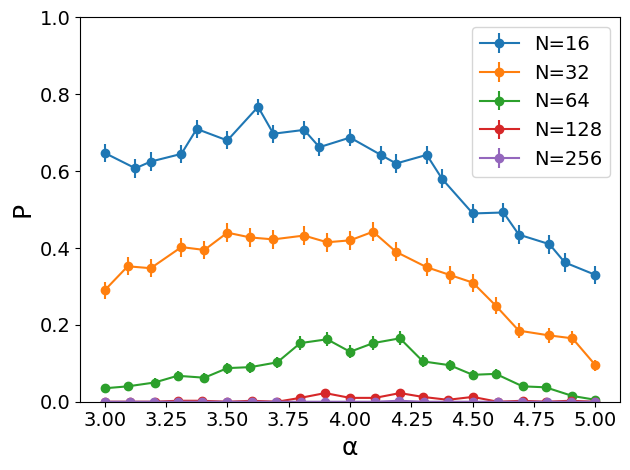

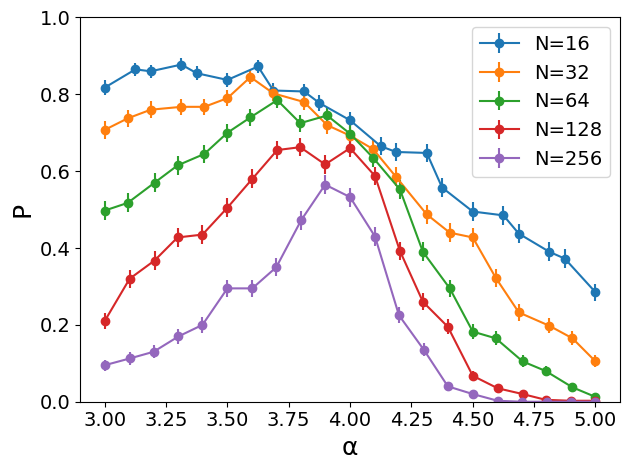

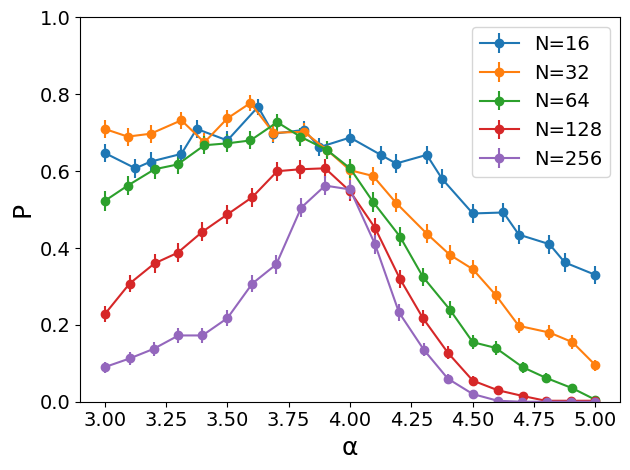

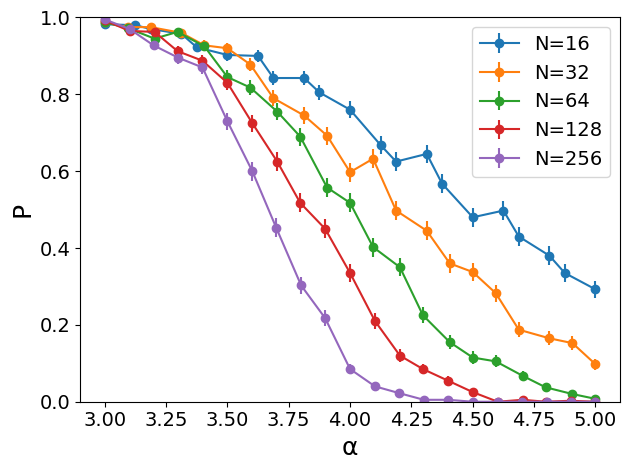

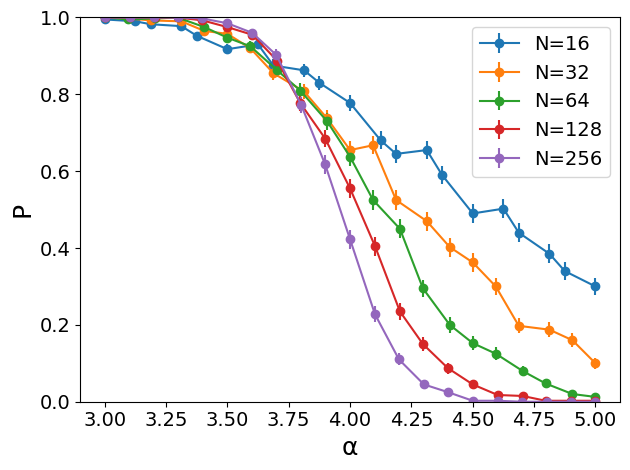

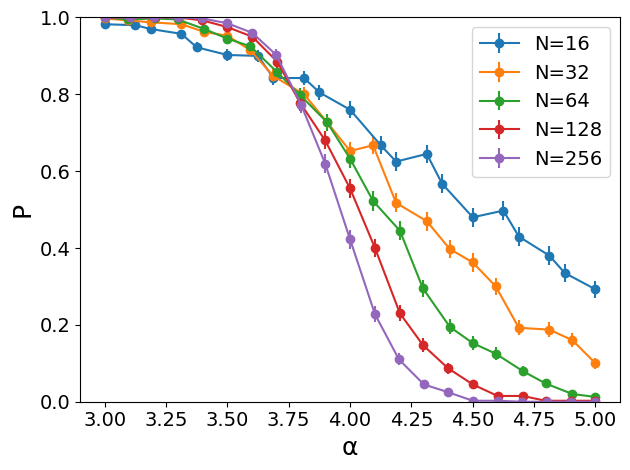

In [16]:
plot_model_curve(ns_3sat_sup_32, curve_type='probability', savename='neurosat_3sat_sup_32.pdf')
plot_model_curve(ns_3sat_sup_512, curve_type='probability', savename='neurosat_3sat_sup_512.pdf')
plot_model_curve(ns_3sat_sup_2n, curve_type='probability', savename='neurosat_3sat_sup_2n.pdf')
plot_model_curve(ns_3sat_unsup_32, curve_type='probability', savename='neurosat_3sat_unsup_32.pdf')
plot_model_curve(ns_3sat_unsup_512, curve_type='probability', savename='neurosat_3sat_unsup_512.pdf')
plot_model_curve(ns_3sat_unsup_2n, curve_type='probability', savename='neurosat_3sat_unsup_2n.pdf')

# Fig. 3

In [17]:
def logistic_fit(alpha, Q, b, v, alpha_N):
    # Implements a more general logistic function (solution of Richards's DE with K=1)
    return 1 / ((1 + Q * np.exp(-b*v*(alpha - alpha_N))) ** (1/v))

def plot_threshold_curve(results_df, task='3SAT', threshold=0., algorithm=None, savename=None):
    p_curves, err_vals, xs, Ns = [], [], [], []
    grouped_df = results_df.groupby('N')
    for N, group in grouped_df:
        alphas, means, sems = [], [], []
        alpha_group = group.groupby('alpha')
        for a, g in alpha_group:
            p_mean, p_sem = g["Solved"].mean(), g["Solved"].std()/np.sqrt(g["Solved"].shape[0])
            alphas.append(a)
            means.append(p_mean)
            sems.append(p_sem)
        p_curves.append(means)
        err_vals.append(sems)
        Ns.append(N)
        xs.append(alphas)

    popts = []
    for i in range(len(p_curves)):
        x, y = xs[i], p_curves[i]
        if task == '3SAT':
            bounds = ([0., -np.inf, 0., 2.], [np.inf, np.inf, np.inf, 6.])
        elif task == '4SAT':
            bounds = ([0., -np.inf, 0., 7.], [np.inf, np.inf, np.inf, 11.])
        elif task == '3COL':
            bounds = ([0., -np.inf, 0., 2.], [np.inf, np.inf, np.inf, 5.])
        else:
            bounds = ([0., -np.inf, 0., 0.], [np.inf, np.inf, np.inf, np.inf])
        popt, _ = curve_fit(logistic_fit, x, y, bounds=bounds, maxfev=10000)
        popts.append(popt)

    for i in range(len(p_curves)):
        x, y, popt, errors = xs[i], p_curves[i], popts[i], err_vals[i]
        plt.errorbar(x, y, yerr=errors, fmt='o', color=N_color_dict[Ns[i]])

        if task == '3SAT':
            min_x, max_x = 3., 5.
        elif task == '4SAT':
            min_x, max_x = 8., 10.
        elif task == '3COL':
            min_x, max_x = 3.25, 5.
        elif task == '5COL':
            min_x, max_x = 10., 13.5
        else:
            raise ValueError('Task not recognized for threshold plotting')

        f = lambda x: logistic_fit(x, *popt)
        fit_x = np.linspace(min_x, max_x, 10000)

        if algorithm == 'QuerySAT' and Ns[i] > 256:
            plt.plot(fit_x, f(fit_x), linestyle='dashed', label=f'N={Ns[i]}', color=N_color_dict[Ns[i]])
        else:
            plt.plot(fit_x, f(fit_x), label=f'N={Ns[i]}', color=N_color_dict[Ns[i]])

    if threshold > 0:
        plt.axvline(x=threshold, color='black', linestyle='--', label=f'Alg. Threshold')

    # Coordinates for arrow (middle of the plot)
    ymid = 0.5
    if algorithm == 'rPI':
        # Arrow pointing left
        xmid = 4.125
        plt.annotate(
            '', xy=(xmid-0.5, ymid), xytext=(xmid, ymid),
            arrowprops=dict(arrowstyle="->", color='gray', lw=2)
        )
    elif algorithm == 'SP':
        # Arrow pointing right
        xmid = 9.
        plt.annotate(
            '', xy=(xmid+0.5, ymid), xytext=(xmid, ymid),
            arrowprops=dict(arrowstyle="->", color='gray', lw=2)
        )
        
    if 'SAT' in task:
        plt.xlabel('α', fontsize=18)
    else:
        plt.xlabel('c', fontsize=18)

    plt.xticks(fontsize=14)
    plt.ylabel('P', fontsize=18)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=14, loc='lower left')
    plt.tight_layout()
    if savename:
        plt.savefig(os.path.join('figures', savename), format="pdf")
    plt.show()

In [18]:
gnn_3col = pd.read_csv(os.path.abspath('../results_evaluation/3COL/3COL_rPI-GNN_ntrials=5.csv'))
querysat_3sat = pd.read_csv(os.path.abspath('../results_evaluation/3SAT/3SAT_QuerySAT_niters=2N_Ntrain=256.csv'))
sp_4sat = pd.read_csv(os.path.abspath('../results_evaluation/4SAT/4SAT_SurveyPropagation_frac-decimated=0.00125.csv'))

In [19]:
gnn_3col['alpha'] = (gnn_3col['M'] / gnn_3col['N'])*2
gnn_3col['Solved'] = gnn_3col['E'].values == 0
gnn_3col = gnn_3col[gnn_3col['N'] >= 128]

querysat_3sat['alpha'] = querysat_3sat['M'] / querysat_3sat['N']
querysat_3sat['Solved'] = querysat_3sat['E'].values == 0

sp_4sat = sp_4sat[sp_4sat['N'] >= 128]
sp_4sat['alpha'] = sp_4sat['M'] / sp_4sat['N']
sp_4sat['Solved'] = sp_4sat['E'].values == 0

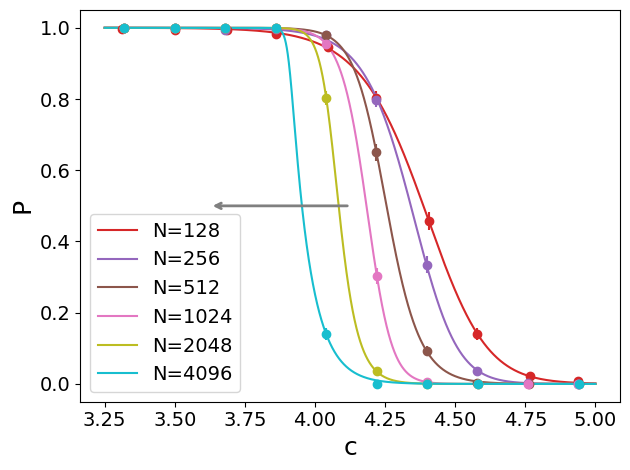

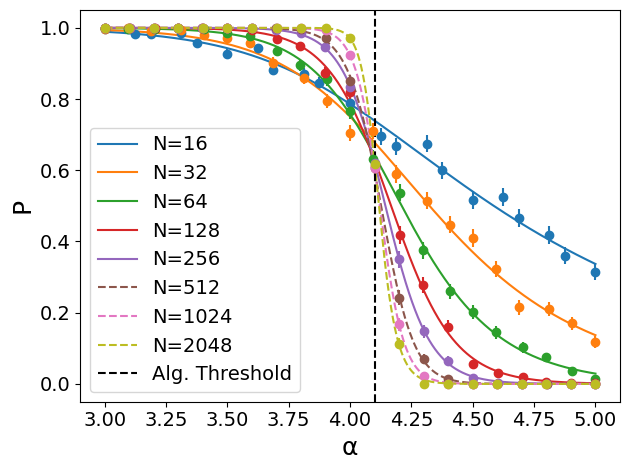

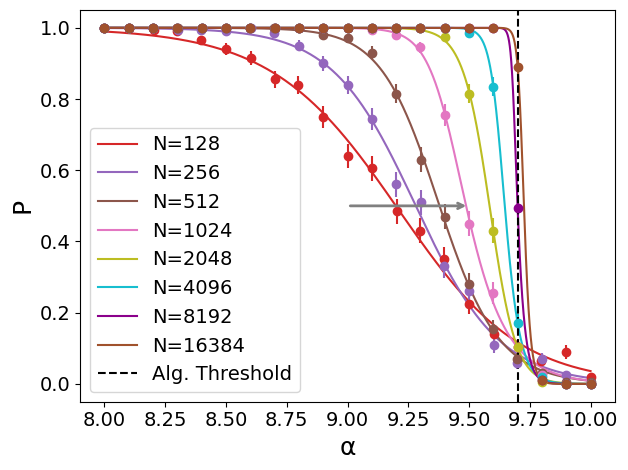

In [20]:
plot_threshold_curve(gnn_3col, task='3COL', algorithm='rPI', savename='rpignn_3col_threshold.pdf')
plot_threshold_curve(querysat_3sat, task='3SAT', algorithm='QuerySAT', threshold=4.1, savename='querysat_3sat_threshold.pdf')
plot_threshold_curve(sp_4sat, task='4SAT', algorithm='SP', threshold=9.7, savename='sp_4sat_threshold.pdf')

# Curves for SP and FMS in large N regimes

In [21]:
def plot_model_curve(results_df, curve_type='probability', task='SAT', savename=None):
    assert curve_type in ['probability', 'ext_energy', 'int_energy'], 'Invalid curve type'
    assert task in ['SAT', 'COL'], 'Invalid task type'

    grouped_df = results_df.groupby('N')
    for N, group in grouped_df:
        if N not in list(N_color_dict.keys()):
            continue
        alphas, means, sems = [], [], []
        alpha_group = group.groupby('alpha')
        for a, g in alpha_group:
            if curve_type == 'probability':
                mean, sem = g["Solved"].mean(), g["Solved"].std()/np.sqrt(g["Solved"].shape[0])
            elif curve_type == 'ext_energy':
                mean, sem = g["E"].mean(), (g["E"].std()/np.sqrt(g["E"].shape[0]))       
            elif curve_type == 'int_energy':
                m = round(a * N)
                mean, sem = g["E"].mean()/m, (g["E"].std()/np.sqrt(g["E"].shape[0]))/m            
            alphas.append(a)
            means.append(mean)
            sems.append(sem)
        plt.errorbar(alphas, means, yerr=sems, fmt='-o', label=f'N={N}', color=N_color_dict[N])
        if curve_type == 'ext_energy':
            plt.yscale('log')

    xlabel = 'α' if task == 'SAT' else 'c'
    plt.xlabel(xlabel, fontsize=18)
    plt.xticks(fontsize=14)
    if curve_type == 'probability':
        plt.ylabel('P', fontsize=18)
    elif curve_type == 'ext_energy' or curve_type == 'int_energy':
        plt.ylabel('E', fontsize=18)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=14)
    plt.tight_layout()
    if savename:
        plt.savefig(os.path.join('figures', savename), format="pdf")
    plt.show()

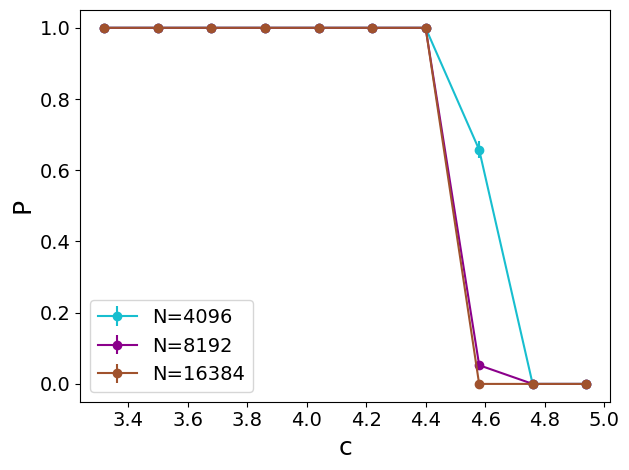

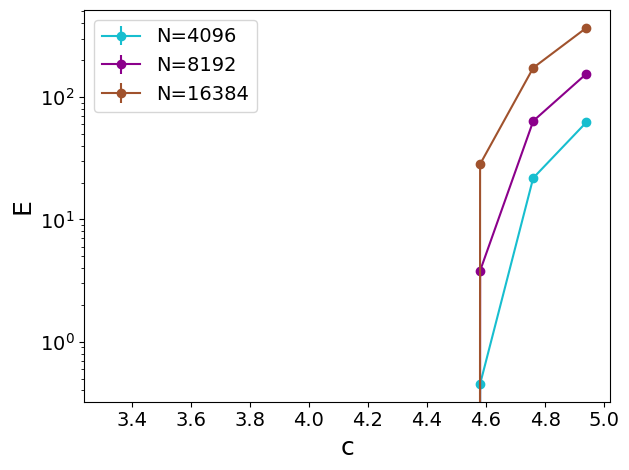

In [22]:
fms_3col = pd.read_csv('../results_evaluation/3COL/3COL_FMScol_eta=0.37_nsteps=625N^2.csv')
fms_3col['alpha'] = fms_3col['M'] / fms_3col['N']*2
fms_3col['Solved'] = fms_3col['E'].values == 0
fms_3col = fms_3col[fms_3col['N'] >= 4096]
plot_model_curve(fms_3col, task='COL', savename='FMS_largeN_3COL_P.pdf')
plot_model_curve(fms_3col, curve_type='ext_energy', task='COL', savename='FMS_largeN_3COL_E.pdf')

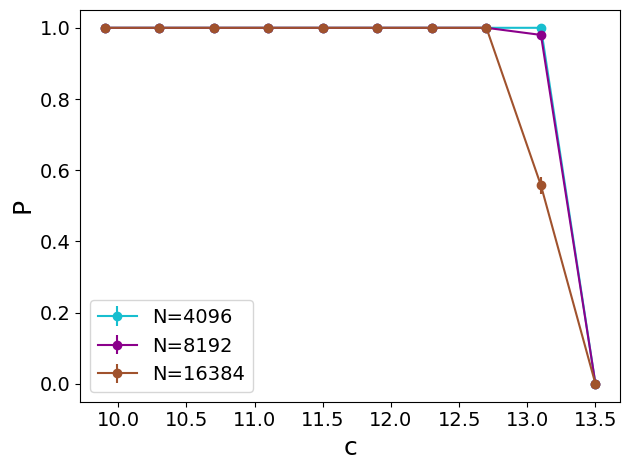

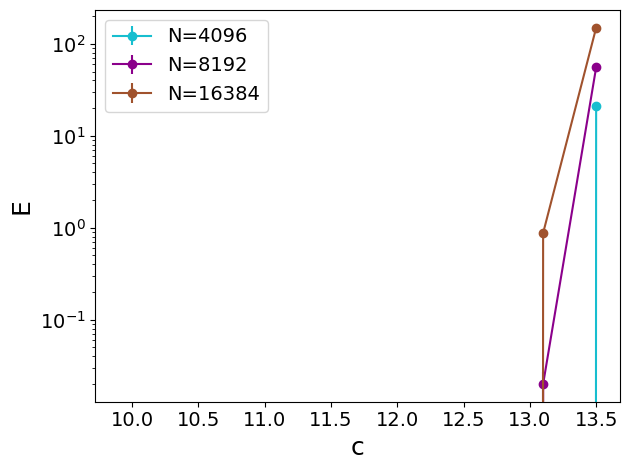

In [23]:
fms_5col = pd.read_csv('../results_evaluation/5COL/5COL_FMScol_eta=0.25_nsteps=625N^2.csv')
fms_5col['alpha'] = fms_5col['M'] / fms_5col['N']*2
fms_5col['Solved'] = fms_5col['E'].values == 0
fms_5col = fms_5col[fms_5col['N'] >= 4096]
plot_model_curve(fms_5col, task='COL', savename='FMS_largeN_5COL_P.pdf')
plot_model_curve(fms_5col, curve_type='ext_energy', task='COL', savename='FMS_largeN_5COL_E.pdf')

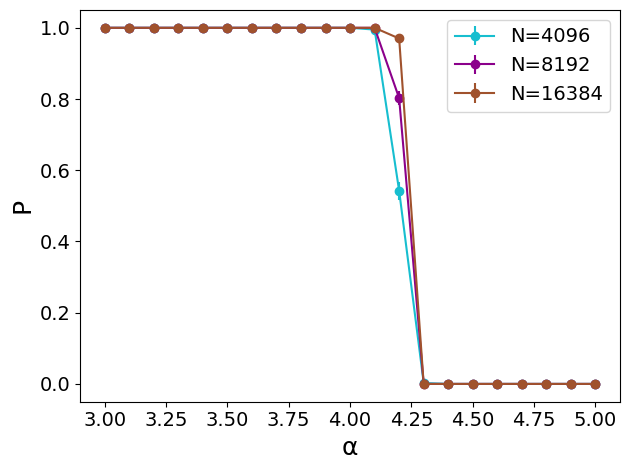

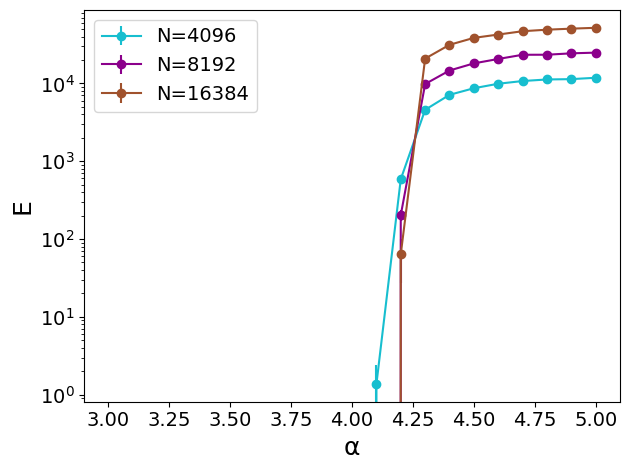

In [24]:
sp_3sat = pd.read_csv('../results_evaluation/3SAT/3SAT_SurveyPropagation_frac-decimated=0.00125.csv')
sp_3sat['alpha'] = sp_3sat['M'] / sp_3sat['N']
sp_3sat['Solved'] = sp_3sat['E'].values == 0
sp_3sat = sp_3sat[sp_3sat['N'] >= 4096]
plot_model_curve(sp_3sat, task='SAT', savename='SP_largeN_3SAT_P.pdf')
plot_model_curve(sp_3sat, curve_type='ext_energy', task='SAT', savename='SP_largeN_3SAT_E.pdf')

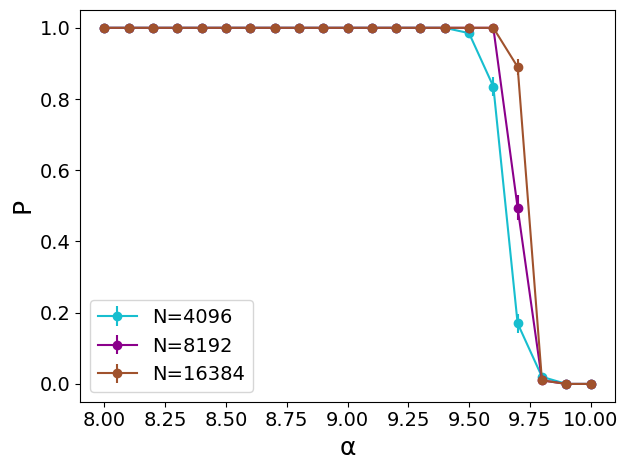

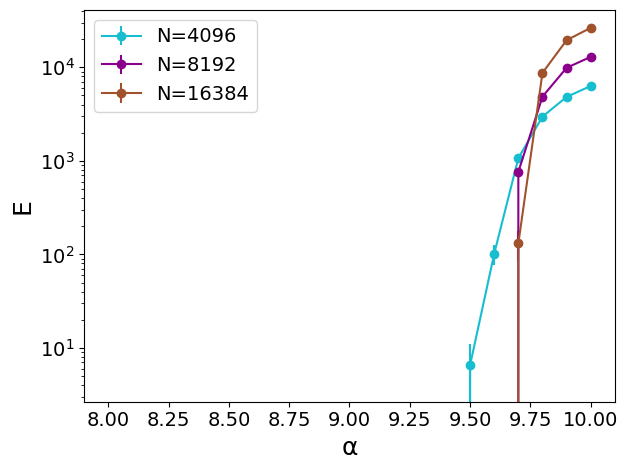

In [25]:
sp_4sat = pd.read_csv('../results_evaluation/4SAT/4SAT_SurveyPropagation_frac-decimated=0.00125.csv')
sp_4sat['alpha'] = sp_4sat['M'] / sp_4sat['N']
sp_4sat['Solved'] = sp_4sat['E'].values == 0
sp_4sat = sp_4sat[sp_4sat['N'] >= 4096]
plot_model_curve(sp_4sat, task='SAT', savename='SP_largeN_4SAT_P.pdf')
plot_model_curve(sp_4sat, curve_type='ext_energy', task='SAT', savename='SP_largeN_4SAT_E.pdf')